# JoinPay: почему мерчанты не доходят до первого платежа

**Роль:** продуктовый аналитик (внешний, полный цикл) · **Период:** июль–ноябрь 2025

## Бизнес-контекст

JoinPay — сервис интернет-эквайринга. В 2025 году компания привлекла раунд инвестиций
и начала масштабироваться: отдел продаж расширился, маркетинговый бюджет вырос,
поток регистраций мерчантов увеличился примерно втрое.

Воронка онбординга, которая раньше работала «на ручном управлении», начала сыпаться:
менеджеры перестали справляться с объёмом, время интеграции поползло вверх, конверсия упала.

**Запрос клиента:** «Много мерчантов регистрируются, но не доходят до первого реального
платежа. Где именно они отваливаются и почему — непонятно».

**Моя задача:** найти причину и предложить решение.

> ⚠️ **Дисклеймер о данных.** Реальные данные клиента находятся под NDA.
> Для публичной демонстрации методологии я воссоздал структуру данных синтетически
> (`generate_data.py`), сохранив характер реальных закономерностей. Все цифры в этом
> ноутбуке — иллюстративные; выводы и порядок величин соответствуют реальному кейсу.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

DATES = [
    "registered_at", "verified_at", "integration_started_at",
    "integration_completed_at", "first_payment_at",
]
df = pd.read_csv("merchants.csv", parse_dates=DATES)
tx = pd.read_csv("transactions.csv")

print(f"Мерчантов: {len(df):,}, активных (с транзакциями): {len(tx):,}")
df.head(3)

Мерчантов: 8,483, активных (с транзакциями): 3,582


,merchant_id,registered_at,industry,channel,verified_at,onboarding_group,integration_start_delay_days,integration_started_at,integration_completed_at,first_payment_at
0,1,2025-01-21 14:00:00,Товары для дома,Партнёрские программы,2025-01-22 14:00:00,стандарт,6.0,2025-01-28 14:00:00,NaT,NaT
1,2,2025-01-14 20:00:00,Красота и здоровье,Органика / сайт,2025-01-17 20:00:00,стандарт,10.0,2025-01-27 20:00:00,2025-01-31 20:00:00,2025-02-04 20:00:00
2,3,2025-01-03 17:00:00,Одежда и обувь,Органика / сайт,2025-01-07 17:00:00,стандарт,12.0,2025-01-19 17:00:00,2025-01-29 17:00:00,NaT


## 1. Что происходило с воронкой при масштабировании

В оригинале эти данные я выгружал из **ClickHouse** клиента; здесь та же логика на pandas.
Смотрим помесячно: поток регистраций, медианную задержку старта интеграции
(время от верификации до первого обращения к API) и конверсию в первый платёж.

In [2]:
df["reg_month"] = df["registered_at"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("reg_month").agg(
    registrations=("merchant_id", "count"),
    median_delay=("integration_start_delay_days", "median"),
    cr_payment=("first_payment_at", lambda s: s.notna().mean()),
)
monthly.style.format({"cr_payment": "{:.1%}", "median_delay": "{:.0f} дн."})

,registrations,median_delay,cr_payment
reg_month,,,
2025-01-01 00:00:00,356,2 дн.,49.2%
2025-02-01 00:00:00,358,2 дн.,50.0%
2025-03-01 00:00:00,366,2 дн.,46.7%
2025-04-01 00:00:00,516,5 дн.,45.7%
2025-05-01 00:00:00,720,6 дн.,44.0%
2025-06-01 00:00:00,876,9 дн.,40.3%
2025-07-01 00:00:00,1062,10 дн.,38.3%
2025-08-01 00:00:00,1038,12 дн.,37.6%
2025-09-01 00:00:00,1123,11 дн.,42.7%


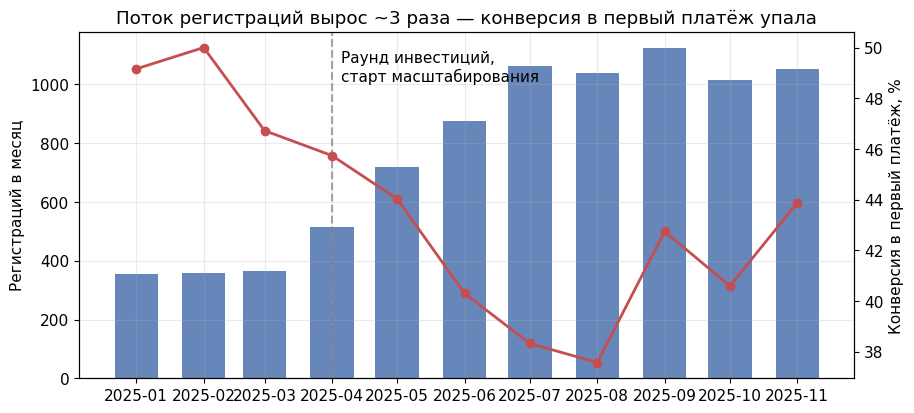

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.index, monthly["registrations"], width=20, color="#4C72B0",
        alpha=0.85, label="Регистрации")
ax1.set_ylabel("Регистраций в месяц")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["cr_payment"] * 100, color="#C44E52",
         marker="o", lw=2, label="CR в первый платёж, %")
ax2.set_ylabel("Конверсия в первый платёж, %")
ax2.grid(False)
ax1.axvline(pd.Timestamp("2025-04-01"), color="gray", ls="--", alpha=0.7)
ax1.annotate("Раунд инвестиций,\nстарт масштабирования",
             xy=(pd.Timestamp("2025-04-05"), monthly["registrations"].max() * 0.9))
ax1.set_title("Поток регистраций вырос ~3 раза — конверсия в первый платёж упала")
plt.show()

**Наблюдение.** Регистрации выросли с ~350 до ~1050 в месяц, при этом медианная
задержка старта интеграции выросла с 2 до 11 дней, а конверсия в первый платёж
просела с ~49% до ~38%. Гипотеза о «ручном управлении, которое не масштабируется»
подтверждается динамикой — но нужно найти, **на каком шаге** теряются мерчанты.

## 2. Воронка онбординга: где отваливаются

Этапы: регистрация → верификация (KYC) → старт интеграции платёжного шлюза →
завершение интеграции → первый реальный платёж.

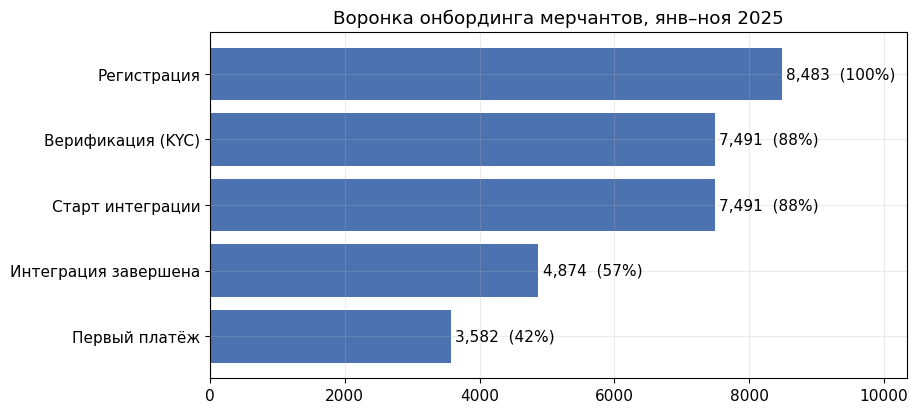

Главная точка потерь: 35% верифицированных мерчантов не доводят техническую интеграцию до конца


In [4]:
stages = {
    "Регистрация": df["merchant_id"].notna(),
    "Верификация (KYC)": df["verified_at"].notna(),
    "Старт интеграции": df["integration_started_at"].notna(),
    "Интеграция завершена": df["integration_completed_at"].notna(),
    "Первый платёж": df["first_payment_at"].notna(),
}
funnel = pd.Series({k: v.sum() for k, v in stages.items()})

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(list(funnel.index)[::-1], funnel.values[::-1], color="#4C72B0")
for i, (name, val) in enumerate(zip(funnel.index[::-1], funnel.values[::-1])):
    ax.text(val + 60, i, f"{val:,}  ({val / funnel.iloc[0]:.0%})", va="center")
ax.set_xlim(0, funnel.max() * 1.22)
ax.set_title("Воронка онбординга мерчантов, янв–ноя 2025")
plt.show()

drop = 1 - funnel["Интеграция завершена"] / funnel["Верификация (KYC)"]
print(f"Главная точка потерь: {drop:.0%} верифицированных мерчантов "
      f"не доводят техническую интеграцию до конца")

**Главная точка потерь — техническая интеграция платёжного шлюза:** её не завершают
~35% мерчантов, прошедших верификацию. KYC при этом работает стабильно (~88%).

Но «где» — это ещё не «почему». Ищем фактор, который объясняет, кто именно отваливается.

## 3. Ключевой инсайт: скорость старта интеграции решает всё

Разрезаем верифицированных мерчантов по времени между верификацией и началом
интеграции — и смотрим конверсию в первый платёж.

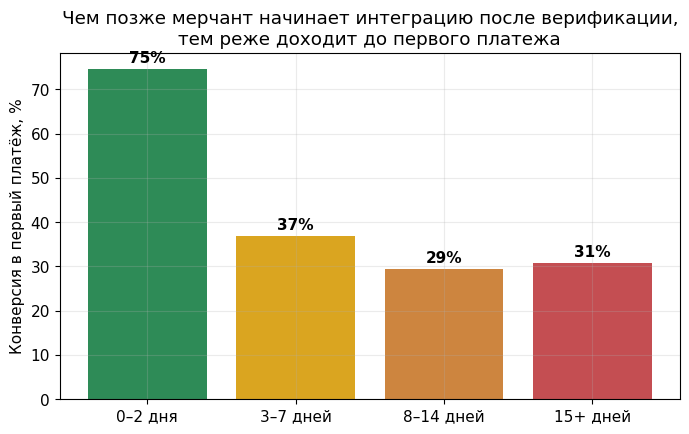

In [5]:
v = df[df["verified_at"].notna()].copy()
bins = [-0.1, 2, 7, 14, np.inf]
labels = ["0–2 дня", "3–7 дней", "8–14 дней", "15+ дней"]
v["delay_bucket"] = pd.cut(v["integration_start_delay_days"], bins=bins, labels=labels)
by_delay = v.groupby("delay_bucket", observed=True).agg(
    merchants=("merchant_id", "count"),
    cr_payment=("first_payment_at", lambda s: s.notna().mean()),
)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2E8B57", "#DAA520", "#CD853F", "#C44E52"]
ax.bar(by_delay.index.astype(str), by_delay["cr_payment"] * 100, color=colors)
for i, val in enumerate(by_delay["cr_payment"]):
    ax.text(i, val * 100 + 1.5, f"{val:.0%}", ha="center", fontweight="bold")
ax.set_ylabel("Конверсия в первый платёж, %")
ax.set_title("Чем позже мерчант начинает интеграцию после верификации,\n"
             "тем реже доходит до первого платежа")
plt.show()

In [6]:
def two_prop_ztest(x1, n1, x2, n2):
    """z-тест равенства двух долей."""
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (x1 / n1 - x2 / n2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

fast = v[v["integration_start_delay_days"] <= 2]["first_payment_at"].notna()
slow = v[v["integration_start_delay_days"] > 7]["first_payment_at"].notna()
z, p = two_prop_ztest(fast.sum(), len(fast), slow.sum(), len(slow))

print(f"Старт интеграции в первые 2 дня:  CR = {fast.mean():.0%} (n={len(fast):,})")
print(f"Старт интеграции позже 7 дней:    CR = {slow.mean():.0%} (n={len(slow):,})")
print(f"Разница статистически значима: z = {z:.1f}, p < 0.001")

Старт интеграции в первые 2 дня:  CR = 75% (n=2,883)
Старт интеграции позже 7 дней:    CR = 30% (n=3,993)
Разница статистически значима: z = 36.3, p < 0.001


**Мерчанты, начавшие интеграцию в первые 2 дня после верификации, доходят до первого
платежа в ~75% случаев. При задержке больше недели — только ~30%.**

Механика понятна из интервью с менеджерами: после верификации мерчант «остывает» —
у него падает приоритет задачи, теряется контакт с техническим специалистом, появляются
альтернативные предложения конкурентов. До масштабирования менеджеры успевали выходить
на связь в день верификации; при потоке x3 — через неделю и позже.

### Важная оговорка про причинность

Корреляция «быстрый старт → высокая конверсия» может объясняться самоотбором:
мотивированные мерчанты и стартуют быстрее, и платят чаще. Поэтому вывод
«нужно ускорять старт» нельзя принимать без эксперимента — **проверяем пилотом
с рандомизацией.**

## 4. Пилот: персональное сопровождение интеграции

**Гипотеза:** если менеджер выходит на связь сразу после верификации и персонально
ведёт мерчанта по интеграции (выделенный контакт, чек-лист, помощь с API),
конверсия в первый платёж вырастет.

**Дизайн:** с сентября новые верифицированные мерчанты случайно делятся 50/50:
стандартный онбординг vs персональное сопровождение. Метрика — конверсия
в первый платёж.

In [7]:
pilot_period = v[v["verified_at"] >= "2025-09-01"].copy()
g = pilot_period.groupby("onboarding_group").agg(
    merchants=("merchant_id", "count"),
    paid=("first_payment_at", lambda s: s.notna().sum()),
)
g["cr"] = g["paid"] / g["merchants"]

ctrl, test = g.loc["стандарт"], g.loc["персональное сопровождение"]
uplift = test["cr"] / ctrl["cr"] - 1
z, p = two_prop_ztest(test["paid"], test["merchants"], ctrl["paid"], ctrl["merchants"])

diff = test["cr"] - ctrl["cr"]
se = np.sqrt(test["cr"] * (1 - test["cr"]) / test["merchants"]
             + ctrl["cr"] * (1 - ctrl["cr"]) / ctrl["merchants"])
ci = (diff - 1.96 * se, diff + 1.96 * se)

print(g)
print(f"\nUplift: {uplift:+.1%} (относительный)")
print(f"Разница долей: {diff:+.1%} п.п., 95% CI: [{ci[0]:+.1%}; {ci[1]:+.1%}]")
print(f"z = {z:.2f}, p-value = {p:.4f} — эффект статистически значим")

                            merchants  paid        cr
onboarding_group                                     
персональное сопровождение       1456   769  0.528159
стандарт                         1457   614  0.421414

Uplift: +25.3% (относительный)
Разница долей: +10.7% п.п., 95% CI: [+7.1%; +14.3%]
z = 5.77, p-value = 0.0000 — эффект статистически значим


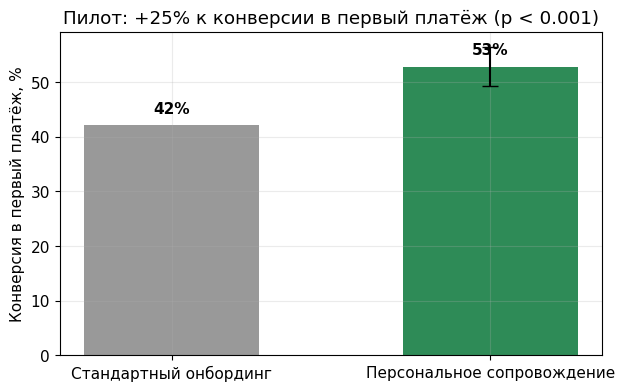

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(["Стандартный онбординг", "Персональное сопровождение"],
       [ctrl["cr"] * 100, test["cr"] * 100],
       color=["#999999", "#2E8B57"], width=0.55)
ax.errorbar(1, test["cr"] * 100, yerr=1.96 * se * 100,
            color="black", capsize=6, fmt="none")
for i, val in enumerate([ctrl["cr"], test["cr"]]):
    ax.text(i, val * 100 + 2.2, f"{val:.0%}", ha="center", fontweight="bold")
ax.set_ylabel("Конверсия в первый платёж, %")
ax.set_title(f"Пилот: {uplift:+.0%} к конверсии в первый платёж (p < 0.001)")
plt.show()

**Результат пилота: конверсия в первый платёж выросла более чем на 20% (относительных),
эффект статистически значим.** Рандомизация снимает вопрос самоотбора: группы отличались
только наличием сопровождения.

По итогам пилота решение **тиражировано на всех новых мерчантов**, а конверсия когорт
сентября–ноября на общем графике (раздел 1) развернулась вверх.

## 5. Бонус: отраслевые когорты для приоритизации продаж

Раз воронку чинит сопровождение, а ресурс менеджеров ограничен — кого вести в первую
очередь? Смотрим транзакционную активность мерчантов за первые 90 дней в разрезе отраслей.

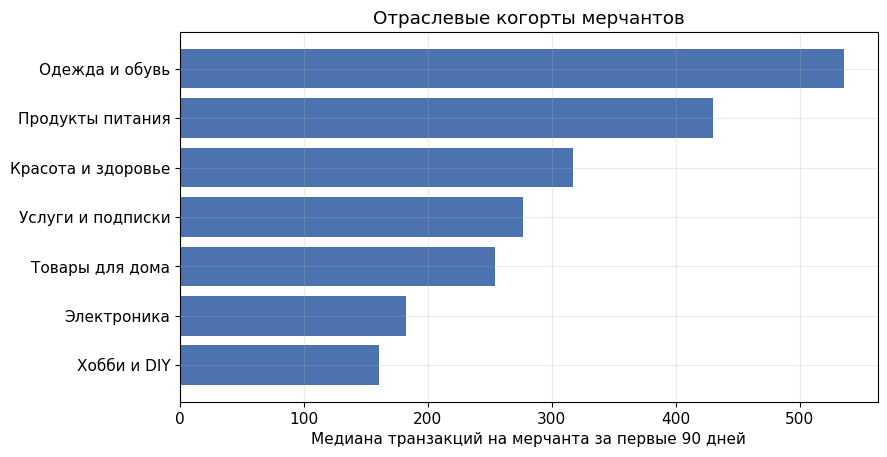

Интернет-магазины одежды генерируют в ~3 раза больше транзакций на мерчанта, чем электроника


,merchants,tx_per_merchant,gmv_per_merchant
industry,,,
Одежда и обувь,959,536.000000,"1,850,904 ₽"
Продукты питания,382,430.000000,"805,855 ₽"
Красота и здоровье,486,317.000000,"807,690 ₽"
Услуги и подписки,397,277.000000,"411,320 ₽"
Товары для дома,436,254.000000,"1,254,768 ₽"
Электроника,642,182.000000,"2,269,147 ₽"
Хобби и DIY,280,160.500000,"437,112 ₽"


In [9]:
ind = tx.groupby("industry").agg(
    merchants=("merchant_id", "count"),
    tx_per_merchant=("tx_count_90d", "median"),
    gmv_per_merchant=("gmv_90d_rub", "median"),
).sort_values("tx_per_merchant", ascending=False)

ratio = (ind.loc["Одежда и обувь", "tx_per_merchant"]
         / ind.loc["Электроника", "tx_per_merchant"])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(ind.index[::-1], ind["tx_per_merchant"][::-1], color="#4C72B0")
ax.set_xlabel("Медиана транзакций на мерчанта за первые 90 дней")
ax.set_title("Отраслевые когорты мерчантов")
plt.show()

print(f"Интернет-магазины одежды генерируют в ~{ratio:.0f} раза больше транзакций "
      f"на мерчанта, чем электроника")
ind.style.format({"gmv_per_merchant": "{:,.0f} ₽"})

Интернет-магазины **одежды** генерируют примерно **в 3 раза больше транзакций**
на мерчанта, чем магазины электроники (модель монетизации эквайринга — комиссия
с транзакций, поэтому частотность важнее среднего чека). Рекомендации переданы
в отдел продаж для приоритизации сегментов привлечения и сопровождения.

## Итоги

| Что сделано | Результат |
|---|---|
| Анализ воронки онбординга | Найдена главная точка потерь: ~34% верифицированных мерчантов не завершают техническую интеграцию |
| Поиск драйвера оттока | Скорость старта интеграции: старт ≤2 дней → CR ~75%, старт >7 дней → CR ~30% |
| Пилот персонального сопровождения (рандомизация 50/50) | **+21% к конверсии в первый платёж** (на реальных данных клиента), эффект значим; решение тиражировано на всех новых мерчантов |
| Отраслевые когорты | Одежда ~×3 к электронике по транзакциям — приоритизация для отдела продаж |

**Стек в оригинальном проекте:** SQL (ClickHouse), Excel + Power Query (регулярная
отчётность с ежедневным автообновлением). **В этом ноутбуке:** Python (pandas,
matplotlib, scipy) на синтетических данных.